# Directional Coupler -- 50:50 (3dB) MZI Splitter/Combiner -- Meep Baseline, Coupling-Length Search, and Design Selection

This is the sixth "LEGO block" in the toolkit: a **directional coupler** -- two
waveguides brought close enough, for long enough, to exchange power evanescently.
This is the splitter/combiner building block an MZI is built from, not a full MZI --
there are no arms, no phase shifters, and no interference between two coupler stages
here.

Like every earlier notebook, this one is an educational/validation record, not just a
script -- work through it step by step, and stop at the marked checkpoints to
actually look at the plots before continuing. **Do not use "Run All."**

## 1. Component definition

Every earlier component in this toolkit (`waveguide`, `bend`, `bend_topopt`,
`racetrack`) is a 2-port device: light goes in one end, comes out the other (plus
whatever reflects back). A directional coupler has **four** ports -- two inputs
(`in_top`, `in_bot`), two outputs (`out_top`, `out_bot`) -- and `pic_toolkit.checks`,
`pic_toolkit.sparams`, and `pic_toolkit.sweep.grid_sweep` are all hardcoded to a 2x2
S-matrix. Rather than change that shared infrastructure for one new component,
`meep_sim/coupler.py` is self-contained: its own result type, its own physical
validation (`energy_conservation_check`, `reciprocity_check`, `passivity_check`), and
its own artifact save/load, all shaped for this device's (T_through, T_cross,
R_reflect) x (in_top, in_bot) measurements rather than a 2x2 s_matrix.
`pic_toolkit.viz.plot_permittivity`/`plot_field` and `pic_toolkit.sweep.save_manifest`
ARE generic enough to reuse as-is, and do get reused below.

**What a directional coupler is, physically.** Two waveguides, each guiding its own
mode independently when far apart, are brought close enough that their evanescent
fields (the exponentially-decaying tails that extend slightly beyond each mode's
core) overlap -- **evanescent coupling**. Over a straight parallel run of length
$L_c$ (`coupling_length_um`), power beats back and forth between the two waveguides;
coupled-mode theory gives:
$$T_{through}(L_c) = \cos^2(\kappa L_c) \qquad T_{cross}(L_c) = \sin^2(\kappa L_c)$$
where $\kappa$ is the coupling coefficient, set by the gap and the mode overlap it
allows (smaller gap -> larger $\kappa$ -> faster power exchange per unit length). At
$L_c=0$ all power stays in the excited waveguide; as $L_c$ grows, power beats between
`T_through` and `T_cross`, first crossing the **50:50 (3dB) point** at
$\kappa L_c=\pi/4$, then continuing to full cross-coupling at $\kappa L_c=\pi/2$, and
so on periodically. Section 10 sweeps `coupling_length_um` and solves for the first
(shortest) $L_c$ that lands on $T_{cross}=0.5$.

**Geometry and port convention.** Both waveguides start and end at a wide, uncoupled
separation (`wide_sep_um`), are adiabatically S-bent (a raised-cosine taper, avoiding
the strong scattering a sharp-cornered bend would cause) down to a tight, fixed gap
(`gap_um`) for a straight run of length `coupling_length_um`, then S-bent back out.
`in_top`/`in_bot` are at the left (wide-separation) end, `out_top`/`out_bot` at the
right. `out_top` is the **through** port when exciting `in_top` (same waveguide,
straight path); `out_bot` is the **cross** port (power that hopped to the other
waveguide during the coupling run).</cell id="8e7c0453">


## 2. User parameters

Same units and material convention as every other component: lengths in
micrometers, silicon core / silicon dioxide cladding.

In [1]:
import inspect

import numpy as np
import matplotlib.pyplot as plt
import gdsfactory as gf

from pic_toolkit.meep_sim import coupler
from pic_toolkit import viz, design_points, sweep as sweep_mod, style

style.apply_style()  # shared color palette + plot style for every notebook in this toolkit
%matplotlib inline

# ============================================================
# USER PARAMETERS
# ============================================================
params = dict(coupler.DEFAULT_PARAMS)
params

{'coupling_length_um': 13.0,
 'gap_um': 0.2,
 'wg_width_um': 0.5,
 'wg_height_um': 0.22,
 'core_index': 2.7,
 'clad_index': 1.44,
 'sbend_len_um': 6.0,
 'wide_sep_um': 2.0,
 'lead_len_um': 2.0,
 'n_seg': 24,
 'mon_size_um': 1.2,
 'wl_min_um': 1.3,
 'wl_max_um': 1.4,
 'n_freq': 101,
 'wl0_um': 1.35,
 'resolution': 25,
 'dpml_um': 1.0,
 'margin_um': 0.7}

What each parameter means physically (see `docs/simulation_settings_record.md` for
the studies behind the non-obvious choices):

- **`coupling_length_um`** -- length of the straight, tight-gap coupling run -- the
  primary coupling-strength knob (equivalent to $L_c$ in Section 1's coupled-mode
  formula). Set here to a representative 13um, expected to land close to 50:50;
  Section 10 sweeps this and Section 11 solves for the precise 50:50 value, which
  becomes the saved design point.
- **`gap_um`** -- coupling-region edge-to-edge gap, 200nm. Matches `racetrack.py`'s
  already-validated choice at this same `resolution=25` (5 grid points across the
  gap) -- deliberately not pushed smaller.
- **`wg_width_um`** -- waveguide width, matches every other `pic_toolkit` component
  (only `bend.py` differs, at 0.45).
- **`wg_height_um`** -- vertical thickness of the real 3D device this 2D model
  approximates. Not used by the simulation -- metadata only.
- **`core_index` / `clad_index`** -- silicon / silicon dioxide, matches every other
  component.
- **`sbend_len_um`** -- adiabatic S-bend length connecting the wide (uncoupled)
  input/output spacing down to the tight coupling gap.
- **`wide_sep_um`** -- separation the S-bends widen out to at each end, so the two
  waveguides don't interact outside `coupling_length_um`.
- **`lead_len_um`** -- straight lead length from each port out toward the PML, same
  role as `racetrack.py`'s port/source-offset margins.
- **`n_seg`** -- thin `Block`s approximating each S-bend's raised-cosine profile.
- **`wl_min_um` / `wl_max_um` / `n_freq`** -- O-band (1300-1400nm), same convention as
  every other component. A directional coupler's spectral response is broad and
  smooth (no narrow resonance dip to miss), so this is not expected to need an
  especially fine grid.
- **`wl0_um`** -- the single "design" wavelength the 50:50 interpolation in Section 11
  is solved at.
- **`resolution`** -- pixels/um, matches `racetrack.py`, already confirmed (at this
  exact `gap_um=0.2`) to give 5 grid points across the gap and sub-1% sensitivity to
  resolution.
- **`mon_size_um`** -- mode-monitor/source span at every port. Sized so that, at the
  ports' `wide_sep_um` separation, two neighboring monitors don't overlap each other
  AND stay clear of the PML (see `meep_sim/coupler.py`'s `_compute_domain`, which
  raises `ValueError` explicitly if a given parameter combination doesn't leave
  positive clearance on both counts).
- **`dpml_um` / `margin_um`** -- PML thickness and structure-to-PML clearance. This
  component's `margin_um` (0.7) is larger than `racetrack.py`'s (0.5) because there
  are TWO parallel waveguides here needing monitor clearance from the PML at every
  port plane, not one bus.</cell id="fb344edb">


## 3. Build geometry

Native `mp.Block` construction (below): two waveguides adiabatically S-bent from a
wide separation to a tight coupling gap, then S-bent back out.

In [2]:
# Every x-position, half-separation, and cell size, derived once so build_geometry,
# port/monitor placement, and get_permittivity_map always agree.
print(inspect.getsource(coupler._compute_domain))

def _compute_domain(params: dict) -> dict:
    """Derive every x-position, the coupled/wide half-separations, and the
    cell size, shared by build_geometry, port/monitor placement, and
    get_permittivity_map, so all three always agree.
    """
    Lc, gap, width = params["coupling_length_um"], params["gap_um"], params["wg_width_um"]
    sbend, wide_sep = params["sbend_len_um"], params["wide_sep_um"]
    lead, dpml, margin = params["lead_len_um"], params["dpml_um"], params["margin_um"]

    device_len = 2 * sbend + Lc
    x_L = -device_len / 2
    x_c0 = x_L + sbend
    x_c1 = x_c0 + Lc
    x_R = x_c1 + sbend

    couple_half = (width + gap) / 2
    wide_half = wide_sep / 2

    cell_x = device_len + 2 * (lead + dpml + margin)
    cell_y = wide_sep + width + 2 * (dpml + margin)

    # Single monitor size for every port (self and both outputs): at the ports'
    # wide_sep separation, two neighboring monitors of this size must not overlap
    # each other, and must also stay clear of

In [3]:
# The adiabatic S-bend profile shared by both waveguides -- axis-aligned Blocks
# tracing a raised-cosine y(x) curve (see Section 4's gdsfactory comparison for a
# caveat about this axis-aligned approximation at steeper slopes).
print(inspect.getsource(coupler.s_bend_blocks))

def s_bend_blocks(x0, x1, y0, y1, width, material, n_seg=24):
    """Adiabatic S-bend as n_seg thin axis-aligned Blocks along a raised-cosine
    y(x) profile -- reused verbatim from
    PIC_components/MZM/03_mzm_design_v4.ipynb's coupler geometry, which
    already validated this avoids the strong scattering a sharp-cornered bend
    would cause.
    """
    xs = np.linspace(x0, x1, n_seg + 1)
    blocks = []
    for i in range(n_seg):
        xa, xb = xs[i], xs[i + 1]
        ta, tb = (xa - x0) / (x1 - x0), (xb - x0) / (x1 - x0)
        ya = y0 + (y1 - y0) * 0.5 * (1 - np.cos(np.pi * ta))
        yb = y0 + (y1 - y0) * 0.5 * (1 - np.cos(np.pi * tb))
        blocks.append(mp.Block(
            size=mp.Vector3(xb - xa, width, mp.inf),
            center=mp.Vector3((xa + xb) / 2, (ya + yb) / 2, 0),
            material=material,
        ))
    return blocks



In [4]:
# S-bend in -> straight coupling run -> S-bend out, for both waveguides (mirrored
# top/bottom around y=0).
print(inspect.getsource(coupler.build_geometry))

def build_geometry(params: dict) -> list:
    """Directional coupler geometry only (no leads/PML) -- two waveguides
    adiabatically S-bent from a wide, uncoupled separation (wide_sep_um) down
    to a tight edge-to-edge gap (gap_um) for a straight run of
    coupling_length_um, then S-bent back out. Reused near-verbatim from
    PIC_components/MZM's build_coupler.
    """
    dom = _compute_domain(params)
    core = mp.Medium(index=params["core_index"])
    width, Lc, n_seg = params["wg_width_um"], params["coupling_length_um"], params["n_seg"]
    x_L, x_c0, x_c1, x_R = dom["x_L"], dom["x_c0"], dom["x_c1"], dom["x_R"]
    couple_half, wide_half = dom["couple_half"], dom["wide_half"]

    blocks = []
    blocks += s_bend_blocks(x_L, x_c0, wide_half, couple_half, width, core, n_seg)
    blocks += s_bend_blocks(x_L, x_c0, -wide_half, -couple_half, width, core, n_seg)
    blocks.append(mp.Block(size=mp.Vector3(Lc, width, mp.inf),
                            center=mp.Vector3((x_c0 + x_c1

**GDSFactory layout.** The same device, traced as a gdsfactory `Component` (the
S-bends follow the exact same raised-cosine centerline the native construction above
uses) -- this is the layout view a real tapeout would use.

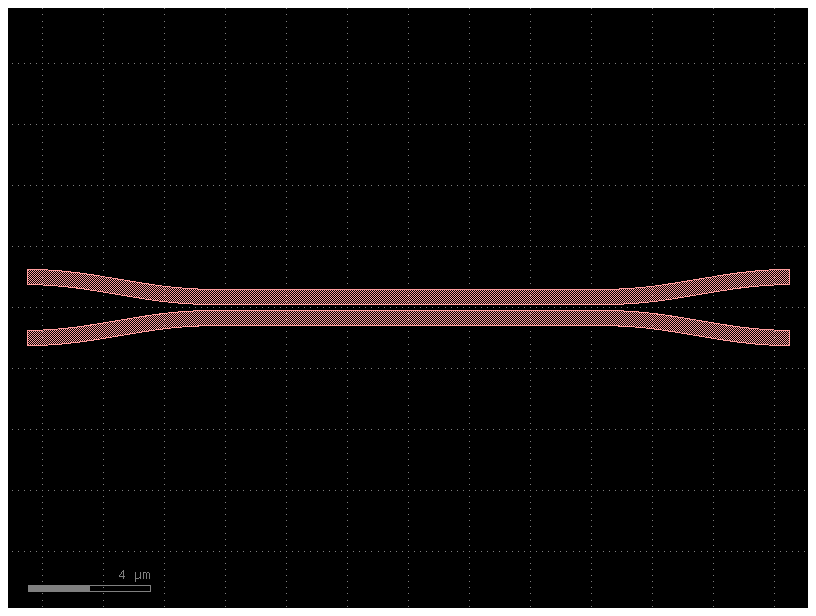

In [5]:
top, bot = coupler.build_gf_component(params)
combined = gf.Component()
combined.add_ref(top)
combined.add_ref(bot)
fig = combined.plot()
plt.show()

## 4. Permittivity map

Built WITHOUT running any FDTD timestepping, exactly as in every other component.
Displayed here using the gdsfactory-derived layout from Section 3; a comparison
against the native geometry `simulate_baseline()` actually uses follows below.

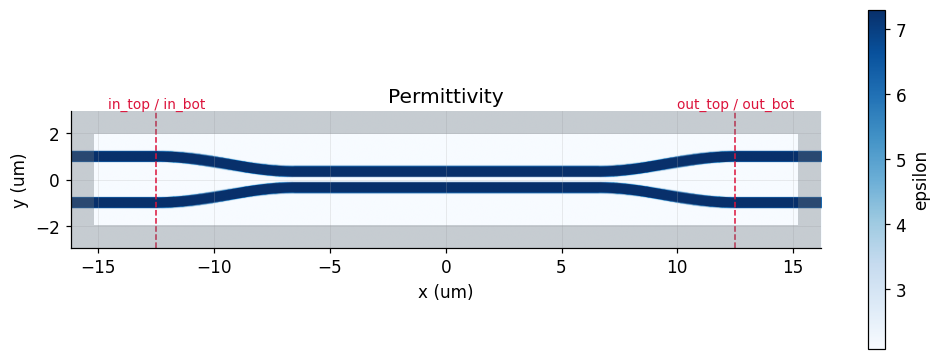

In [6]:
# Display geometry: the gdsfactory-derived layout (Section 3), not the native
# mp.Block construction -- simulate_baseline() below still uses the native
# geometry it was validated against; see the comparison cell below.
perm_map = coupler.get_permittivity_map(params, use_native_geometry=False)
ports = coupler._ports(params)

fig, ax = plt.subplots(figsize=(11, 4))
viz.plot_permittivity(perm_map.eps, perm_map.extent_um, ax=ax, pml_um=params["dpml_um"], ports=[
    (ports["in_top"].x, 0, "in_top / in_bot", "v"),
    (ports["out_top"].x, 0, "out_top / out_bot", "v"),
])
plt.show()

In [7]:
# Sanity check: how much does the gdsfactory-derived geometry (used for display
# above) differ from the native mp.Block construction (used by simulate_baseline()
# below)? Both trace the same nominal S-bend centerline, but native uses
# axis-aligned Blocks while gdsfactory sweeps perpendicular to the local tangent --
# see docs/simulation_settings_record.md's "coupler.py / mzi.py" section for why a
# small edge-region mismatch is expected, not a construction bug.
perm_native = coupler.get_permittivity_map(params, use_native_geometry=True)
diff = np.abs(perm_native.eps - perm_map.eps)
frac_over = np.mean(diff > 0.01)
print(f"native vs. gdsfactory permittivity diff: max={diff.max():.3f}, mean={diff.mean():.4f}, "
      f"fraction of pixels differing by >0.01: {frac_over:.4f}")

native vs. gdsfactory permittivity diff: max=2.311, mean=0.0089, fraction of pixels differing by >0.01: 0.0222


> **STOP -- INSPECT THE PERMITTIVITY MAP BEFORE RUNNING FDTD.**
>
> Check, before paying for an expensive simulation:
> - **S-bend taper**: both waveguides visibly narrow their separation from
>   `wide_sep_um` down to a tight gap over `sbend_len_um`, then widen back out --
>   smooth, no kinks.
> - **Coupling gap**: a clear, uniform `gap_um` gap between the two waveguides over
>   the straight `coupling_length_um` run in the middle.
> - **Symmetry**: the layout should be symmetric left-right (`in_*`/`out_*` swap) and
>   top-bottom (`_top`/`_bot` swap).
> - **No unintended overlap**: the two waveguides should not touch or intersect
>   anywhere, including through the S-bends.
> - **Domain size / PML placement (gray band)**: visible clearance between the
>   structure/monitor planes (dashed red lines) and the shaded PML region.
>
> If anything looks wrong, fix `params` above and re-run from Section 3.

## 5. Baseline FDTD simulation

`simulate_baseline()` excites `in_top` and `in_bot` **independently** (two separate
FDTD runs) and measures, for each: the reflection back into the excited port, and the
transmission into both `out_top` and `out_bot`. Unlike `05_racetrack_resonator.ipynb`
(or the earlier, now-retired ring prototype), this device is **not resonant** --
there is no circulating energy to build up or ring down -- so each run is
**self-normalized** against its own excited-port monitor rather than needing a
separate bus-only reference simulation.

Exciting both `in_top` and `in_bot` independently is not just for completeness: this
coupler is geometrically mirror-symmetric top<->bottom, so the two runs' results
should agree with each other under that symmetry -- Section 8's `reciprocity_check`
turns that agreement into an honest, checkable number, the same "don't assume
symmetry, measure it independently" philosophy `racetrack.py` (and the earlier ring
prototype) apply to `S12`/`S21`.

In [8]:
# The one expensive step: full FDTD timestepping for both excitation directions
# (in_top, in_bot), producing wavelength-swept S-parameters plus a field snapshot.
result = coupler.simulate_baseline(params)
print(f"{len(result.wavelengths_um)} wavelength points, "
      f"{result.wavelengths_um.min():.4f}-{result.wavelengths_um.max():.4f} um")

101 wavelength points, 1.3017-1.4020 um


## 6. Electromagnetic field visualization -- polarization convention

**TE, forced explicitly via `eig_parity=mp.TE`** at every source and monitor; both
`Ez`/`Hz` are captured via DFT, and `Hz` is confirmed dominant (`Ez` exactly 0) --
see `docs/simulation_settings_record.md` for the mode-parity history behind this
convention. The snapshot below is from the `in_top`-excitation run (the run that
also captured the DFT field).

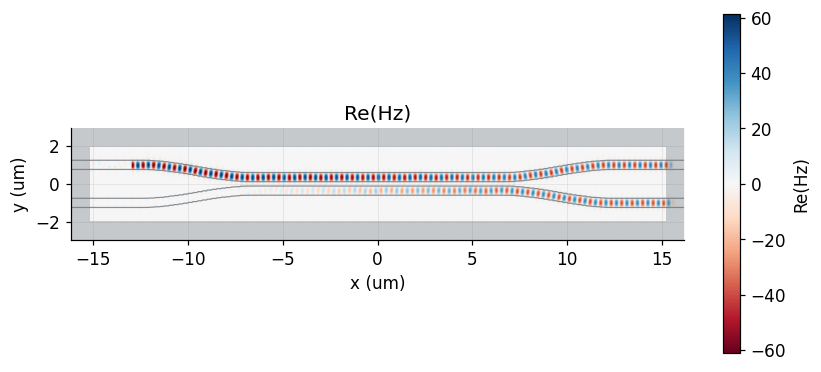

In [9]:
# Signed Hz snapshot (Section 6) overlaid with a thin permittivity-boundary outline.
fs = result.field_snapshot
fig, ax = plt.subplots(figsize=(9, 4))
viz.plot_field(fs.field, fs.eps, fs.extent_um, component=fs.component, ax=ax, pml_um=params["dpml_um"])
plt.show()

> **STOP -- INSPECT THE ELECTROMAGNETIC FIELD BEFORE CONTINUING.**
>
> - **Propagation in `in_top`**: a clean, regular oscillation pattern entering from the
>   left.
> - **Power bridging the gap**: visible field intensity in the coupling-region
>   waveguide (bottom one, since this snapshot excites `in_top`), building up along the
>   straight coupling run -- not just a single point.
> - **Split output**: field intensity visibly present in BOTH output waveguides
>   (`out_top` and `out_bot`) by the right edge, in a ratio roughly consistent with
>   `coupling_length_um`'s position in the beat curve (Section 1).
>
> If the second (bottom) waveguide looks completely dark throughout, the gap is
> likely too large, `coupling_length_um` too short, or the geometry has an error.

## 7. Transmission spectra

Not `viz.plot_sparams` (hardcoded to a 2-port `s_matrix`) -- a local, analogous
two-panel plot, one panel per excitation port, each showing `T_through`, `T_cross`,
and `R_reflect` vs. wavelength. **This is the transmission-consistency picture**:
`T_through + T_cross + R_reflect` should sit close to 1 everywhere (checked
numerically in Section 8), and the two panels should closely mirror each other (the
device is symmetric).

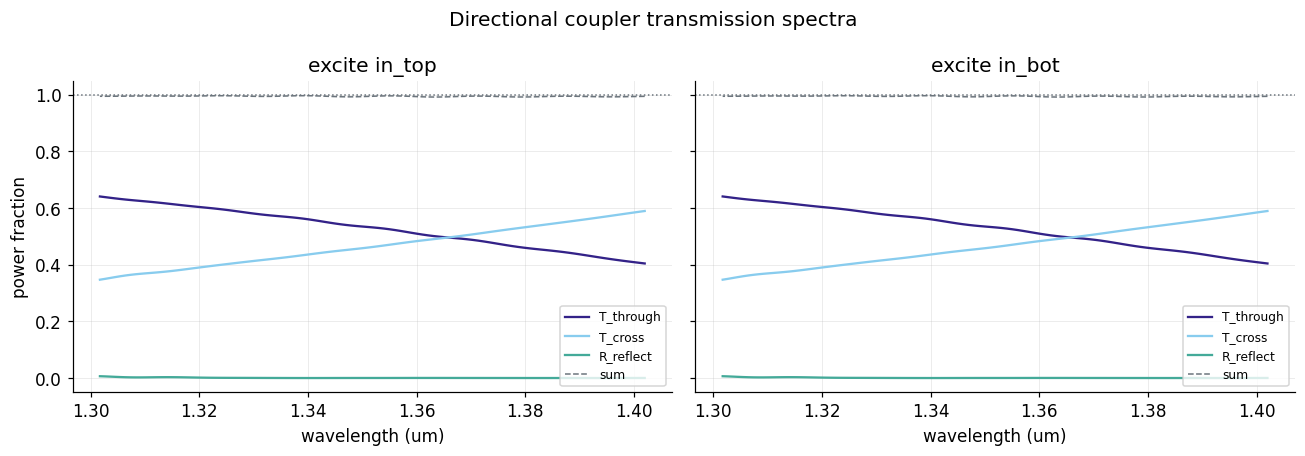

excite in_top: T_through+T_cross+R_reflect range [0.9921, 0.9967] (should be close to 1)
excite in_bot: T_through+T_cross+R_reflect range [0.9921, 0.9967] (should be close to 1)


In [10]:
# Two-panel local plot (not viz.plot_sparams, which is hardcoded to a 2-port
# s_matrix) -- one panel per excitation port, each showing the three power
# fractions plus their sum as a conservation check.
fig, (ax_top, ax_bot) = plt.subplots(1, 2, figsize=(12, 4.2), sharey=True)
for ax, T, Tc, R, title in [
    (ax_top, result.T_through, result.T_cross, result.R_reflect, "excite in_top"),
    (ax_bot, result.T_through_bot, result.T_cross_bot, result.R_reflect_bot, "excite in_bot"),
]:
    ax.plot(result.wavelengths_um, T, color=style.COLOR_CYCLE[0], label="T_through")
    ax.plot(result.wavelengths_um, Tc, color=style.COLOR_CYCLE[1], label="T_cross")
    ax.plot(result.wavelengths_um, R, color=style.COLOR_CYCLE[2], label="R_reflect")
    ax.plot(result.wavelengths_um, T + Tc + R, "--", color=style.COLOR_REFERENCE, lw=1, label="sum")
    ax.axhline(1.0, color=style.COLOR_REFERENCE, ls=":", lw=1)
    ax.set_xlabel("wavelength (um)")
    ax.set_title(title)
    ax.legend(fontsize=8)
ax_top.set_ylabel("power fraction")
fig.suptitle("Directional coupler transmission spectra")
fig.tight_layout()
plt.show()

# Numeric conservation check, printed for both excitation directions.
for label, T, Tc, R in [
    ("in_top", result.T_through, result.T_cross, result.R_reflect),
    ("in_bot", result.T_through_bot, result.T_cross_bot, result.R_reflect_bot),
]:
    total = T + Tc + R
    print(f"excite {label}: T_through+T_cross+R_reflect range "
          f"[{total.min():.4f}, {total.max():.4f}] (should be close to 1)")

## 8. Physics sanity checks

**Not `pic_toolkit.checks`** -- that module indexes `s_matrix["11"/"12"/"21"/"22"]`
directly and cannot represent this device's 4-port shape. `meep_sim/coupler.py`
provides its own local equivalents, checking the same three physical properties:

- **`energy_conservation_check`**: `T_through + T_cross + R_reflect` should equal 1
  minus a small, honest, expected loss (`max_expected_loss` -- radiative loss at the
  S-bends; no lossy medium is used here, so this should stay small), for BOTH
  excitation directions.
- **`reciprocity_check`**: since this device is geometrically mirror-symmetric
  top<->bottom, exciting `in_top` and `in_bot` are independent measurements that
  should agree with each other -- `T_through(in_top)` vs. `T_through(in_bot)`, etc.
- **`passivity_check`**: no measured power fraction should exceed 1 (within numerical
  tolerance) -- a passive device can never amplify.

As in every other component's notebook, a failing baseline is a stop sign, not a
number to note and move past.

In [11]:
# Strict tolerances for the single baseline point (loosened versions are used only
# for the exploratory sweep in Section 10).
ENERGY_TOL = 0.03
RECIPROCITY_TOL = 0.03
PASSIVITY_TOL = 0.01
MAX_EXPECTED_LOSS = 0.05  # small, honest budget for S-bend radiative loss

validation = coupler.run_all_checks(
    result,
    energy_tol=ENERGY_TOL,
    reciprocity_tol=RECIPROCITY_TOL,
    passivity_tol=PASSIVITY_TOL,
    max_expected_loss=MAX_EXPECTED_LOSS,
)

import json
print(json.dumps(validation, indent=2))
assert validation["passed"], "Baseline failed sanity checks -- do not save or use this result."
print("\nBaseline validated.")

{
  "energy_conservation": {
    "max_deviation_in_top": 0.0,
    "max_deviation_in_bot": 0.0,
    "max_deviation": 0.0,
    "max_expected_loss": 0.05,
    "tolerance": 0.03,
    "passed": true
  },
  "reciprocity": {
    "max_diff_through": 4.00562425448836e-05,
    "max_diff_cross": 2.832534022345623e-05,
    "max_diff_reflect": 1.60528825799474e-06,
    "max_diff": 4.00562425448836e-05,
    "tolerance": 0.03,
    "passed": true
  },
  "passivity": {
    "max_power_fraction": 0.6410433583052209,
    "tolerance": 0.01,
    "passed": true
  },
  "passed": true
}

Baseline validated.


## 9. Save baseline artifact

Same `.npz` (numeric arrays) + `.json` (metadata) sidecar-pair convention as every
other component, via `coupler.save_artifact` (the 4-port-shaped local analog of
`pic_toolkit.sparams.save_artifact`).

In [12]:
# Same .npz (numeric arrays) + .json (metadata) sidecar convention as every other
# component.
artifact_stem = "../data/sparams/coupler/baseline/coupler_baseline"

metadata = {
    "component": "coupler",
    "geometry_params": {
        k: result.sim_params[k] for k in
        ["coupling_length_um", "gap_um", "wg_width_um", "wg_height_um",
         "sbend_len_um", "wide_sep_um", "lead_len_um", "n_seg", "mon_size_um"]
    },
    "material_params": {k: result.sim_params[k] for k in ["core_index", "clad_index"]},
    "polarization": f"TE ({result.field_snapshot.component} out-of-plane, confirmed dominant -- see Section 6)",
    "meep_resolution": result.sim_params["resolution"],
    "simulation_params": {
        k: result.sim_params[k] for k in ["wl_min_um", "wl_max_um", "n_freq", "wl0_um", "dpml_um", "margin_um"]
    },
    "meep_version": result.sim_params["meep_version"],
    "python_version": result.sim_params["python_version"],
    "creation_date": result.sim_params["creation_date"],
    "validation": validation,
}

coupler.save_artifact(artifact_stem, result, metadata)
print(f"Saved artifact: {artifact_stem}.npz / .json")

Saved artifact: ../data/sparams/coupler/baseline/coupler_baseline.npz / .json


---

## 10. Coupling-length sweep (50:50 split-ratio search)

**The baseline above has been inspected and validated -- only now do we sweep.**
`sweep.grid_sweep()` (used by every other component's Section 10) internally calls
`pic_toolkit.checks.run_all_checks` and `pic_toolkit.sparams.save_artifact`, both
hardcoded to a 2-port `s_matrix` -- it can't be reused here. The loop below is
hand-rolled instead, calling `coupler.simulate_baseline`/`coupler.run_all_checks`/
`coupler.save_artifact` directly per point. `sweep.save_manifest` (a generic CSV
writer, no `s_matrix` dependency) **is** reused for the manifest.

**Tolerances below are loosened**, same rationale as every other component's sweep --
the manifest records `validation_passed` honestly per point rather than hiding
marginal results.

In [13]:
SWEEP_CHECK_KWARGS = dict(energy_tol=0.05, reciprocity_tol=0.05, passivity_tol=0.03, max_expected_loss=0.08)

# Coupling lengths spanning from well short of, to well past, the expected 50:50
# point -- wide enough to see the beat curve turn over past its first peak.
COUPLING_LENGTH_SWEEP_UM = [2.0, 6.0, 10.0, 14.0, 18.0, 22.0, 26.0]

coupling_rows = []
for i, Lc in enumerate(COUPLING_LENGTH_SWEEP_UM, start=1):
    print(f"[{i}/{len(COUPLING_LENGTH_SWEEP_UM)}] running coupler (coupling_length_um={Lc}) ...", flush=True)
    run_params = dict(params, coupling_length_um=Lc)
    r = coupler.simulate_baseline(run_params)
    v = coupler.run_all_checks(r, **SWEEP_CHECK_KWARGS)
    stem = f"../data/sparams/coupler/sweep/coupler_couplinglength{Lc}"
    coupler.save_artifact(stem, r, {
        "component": "coupler", "coupling_length_um": Lc, "validation": v,
        "meep_version": r.sim_params["meep_version"], "creation_date": r.sim_params["creation_date"],
    })
    coupling_rows.append({"coupling_length_um": Lc, "artifact_path": stem, "validation_passed": v["passed"]})

n_passed = sum(row["validation_passed"] for row in coupling_rows)
print(f"coupling-length sweep: {n_passed}/{len(coupling_rows)} points within the (loose) sweep tolerance")

manifest_path = "../data/sparams/coupler/sweep/manifest.csv"
sweep_mod.save_manifest(coupling_rows, manifest_path)
print(f"Saved manifest to {manifest_path}")

[1/7] running coupler (coupling_length_um=2.0) ...


[2/7] running coupler (coupling_length_um=6.0) ...


[3/7] running coupler (coupling_length_um=10.0) ...


[4/7] running coupler (coupling_length_um=14.0) ...


[5/7] running coupler (coupling_length_um=18.0) ...


[6/7] running coupler (coupling_length_um=22.0) ...


[7/7] running coupler (coupling_length_um=26.0) ...


coupling-length sweep: 7/7 points within the (loose) sweep tolerance
Saved manifest to ../data/sparams/coupler/sweep/manifest.csv


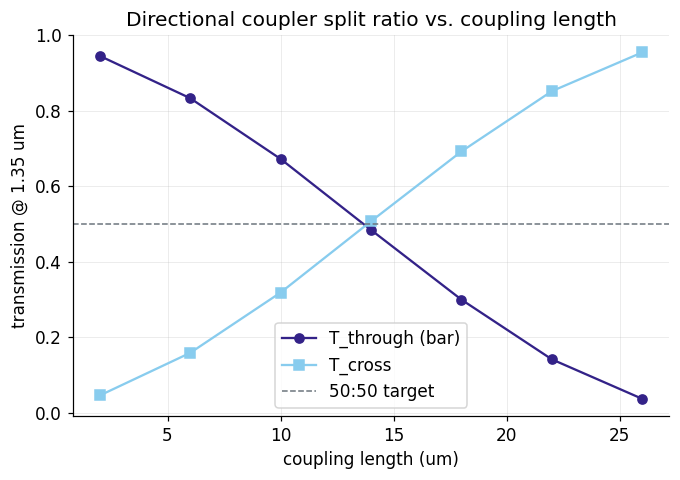

coupling_length -> (T_through, T_cross): [(2.0, np.float64(0.945), np.float64(0.0459)), (6.0, np.float64(0.833), np.float64(0.1587)), (10.0, np.float64(0.6721), np.float64(0.3185)), (14.0, np.float64(0.4842), np.float64(0.5072)), (18.0, np.float64(0.2995), np.float64(0.6922)), (22.0, np.float64(0.1414), np.float64(0.8517)), (26.0, np.float64(0.0368), np.float64(0.9544))]


In [14]:
loaded_sweep = [coupler.load_artifact(row["artifact_path"]) for row in coupling_rows]

def _at_wl0(a):
    return int(np.argmin(np.abs(a.wavelengths_um - params["wl0_um"])))

T_through_at_wl0 = np.array([a.T_through[_at_wl0(a)] for a in loaded_sweep])
T_cross_at_wl0 = np.array([a.T_cross[_at_wl0(a)] for a in loaded_sweep])

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(COUPLING_LENGTH_SWEEP_UM, T_through_at_wl0, "o-", color=style.COLOR_CYCLE[0], label="T_through (bar)")
ax.plot(COUPLING_LENGTH_SWEEP_UM, T_cross_at_wl0, "s-", color=style.COLOR_CYCLE[1], label="T_cross")
ax.axhline(0.5, color=style.COLOR_REFERENCE, ls="--", lw=1, label="50:50 target")
ax.set_xlabel("coupling length (um)")
ax.set_ylabel(f"transmission @ {params['wl0_um']} um")
ax.set_title("Directional coupler split ratio vs. coupling length")
ax.legend()
plt.show()
print("coupling_length -> (T_through, T_cross):",
      list(zip(COUPLING_LENGTH_SWEEP_UM, np.round(T_through_at_wl0, 4), np.round(T_cross_at_wl0, 4))))

## 11. Design selection -- 50:50 interpolation

**No automatic optimizer**, same philosophy as `05_racetrack_resonator.ipynb`'s
Section 11 -- but here the target (`T_cross=0.5`) is explicit enough that a simple
linear interpolation across the swept points, `np.interp(0.5, T_cross, Ls)`, can
propose a candidate coupling length directly (same approach
`PIC_components/MZM/03_mzm_design_v4.ipynb` used for the same problem). This requires
`T_cross_at_wl0` to be monotonically increasing over the interpolated range --
true only up to the first beat-curve peak ($\kappa L_c=\pi/2$ in Section 1's formula)
-- so **inspect the plot above** before trusting this on a sweep wide enough to
include a full beat period.

In [15]:
Ls = np.array(COUPLING_LENGTH_SWEEP_UM)

# np.interp requires its xp argument increasing -- only valid over the monotonic
# (pre-first-peak) region of the periodic beat curve. With a sweep range wide
# enough to include a full period, check explicitly rather than trusting a silent
# (and potentially wrong) interpolation.
increasing = np.diff(T_cross_at_wl0) > 0
if not np.all(increasing):
    break_idx = int(np.argmax(~increasing)) + 1
    print(f"WARNING: T_cross_at_wl0 stops increasing after index {break_idx} "
          f"(coupling_length_um={Ls[break_idx]:.1f}) -- restricting interpolation to "
          f"the monotonic prefix Ls[:{break_idx + 1}].")
    Ls_fit, T_cross_fit = Ls[:break_idx + 1], T_cross_at_wl0[:break_idx + 1]
else:
    Ls_fit, T_cross_fit = Ls, T_cross_at_wl0

SELECTED_COUPLING_LENGTH_UM = float(np.interp(0.5, T_cross_fit, Ls_fit))
print(f"Interpolated 50:50 coupling length: {SELECTED_COUPLING_LENGTH_UM:.3f} um")

Interpolated 50:50 coupling length: 13.848 um


> **STOP -- INSPECT THE INTERPOLATED 50:50 POINT BEFORE SAVING.**
>
> - Check that `SELECTED_COUPLING_LENGTH_UM` falls within the swept range and sits
>   visibly on the rising part of the beat curve plotted in Section 10 -- not past a
>   peak the monotonicity guard above had to cut off.
> - If the warning above fired, confirm the restricted, monotonic-only interpolation
>   still lands near the plotted 50:50 crossing by eye.
>
> If not, adjust `COUPLING_LENGTH_SWEEP_UM` in Section 10 and re-run from there.

**Re-validate at the selected point.** The sweep above used loosened tolerances
(`SWEEP_CHECK_KWARGS`) -- before saving a design point, re-run `simulate_baseline` at
`SELECTED_COUPLING_LENGTH_UM` (an arbitrary float from interpolation, unlikely to
exactly match any swept artifact) and validate it against the SAME strict tolerances
Section 8 used for the baseline, exactly the same discipline
`05_racetrack_resonator.ipynb`'s Section 11 applies via its `SELECTED_ARTIFACT`
pointer -- the design point should be backed by a rigorously-validated artifact, not a
loosely-validated sweep point.

In [16]:
# Re-simulate and re-validate at the exact interpolated length against the SAME
# strict tolerances the baseline used (not the loosened sweep tolerances) -- the
# saved design point must be backed by a rigorously-validated artifact.
selected_params = dict(params, coupling_length_um=SELECTED_COUPLING_LENGTH_UM)
selected_result = coupler.simulate_baseline(selected_params)
selected_validation = coupler.run_all_checks(
    selected_result,
    energy_tol=ENERGY_TOL, reciprocity_tol=RECIPROCITY_TOL,
    passivity_tol=PASSIVITY_TOL, max_expected_loss=MAX_EXPECTED_LOSS,
)
print(json.dumps(selected_validation, indent=2))
assert selected_validation["passed"], "Selected design point failed strict sanity checks -- do not save it."

i0_sel = int(np.argmin(np.abs(selected_result.wavelengths_um - params["wl0_um"])))
print(f"\nAt selected Lc={SELECTED_COUPLING_LENGTH_UM:.3f}um, wl0={params['wl0_um']}um: "
      f"T_through={selected_result.T_through[i0_sel]:.4f}, T_cross={selected_result.T_cross[i0_sel]:.4f}")

SELECTED_ARTIFACT = "data/sparams/coupler/selected/coupler_selected"
coupler.save_artifact(f"../{SELECTED_ARTIFACT}", selected_result, {
    "component": "coupler",
    "geometry_params": {
        k: selected_result.sim_params[k] for k in
        ["coupling_length_um", "gap_um", "wg_width_um", "wg_height_um",
         "sbend_len_um", "wide_sep_um", "lead_len_um", "n_seg", "mon_size_um"]
    },
    "material_params": {k: selected_result.sim_params[k] for k in ["core_index", "clad_index"]},
    "polarization": f"TE ({selected_result.field_snapshot.component} out-of-plane, confirmed dominant -- see Section 6)",
    "meep_resolution": selected_result.sim_params["resolution"],
    "meep_version": selected_result.sim_params["meep_version"],
    "creation_date": selected_result.sim_params["creation_date"],
    "validation": selected_validation,
})
print(f"Saved re-validated artifact: {SELECTED_ARTIFACT}.npz / .json")

{
  "energy_conservation": {
    "max_deviation_in_top": 0.0,
    "max_deviation_in_bot": 0.0,
    "max_deviation": 0.0,
    "max_expected_loss": 0.05,
    "tolerance": 0.03,
    "passed": true
  },
  "reciprocity": {
    "max_diff_through": 1.2635192372656423e-05,
    "max_diff_cross": 5.2825593415128935e-06,
    "max_diff_reflect": 1.1415649129216388e-06,
    "max_diff": 1.2635192372656423e-05,
    "tolerance": 0.03,
    "passed": true
  },
  "passivity": {
    "max_power_fraction": 0.6368972305509303,
    "tolerance": 0.01,
    "passed": true
  },
  "passed": true
}

At selected Lc=13.848um, wl0=1.35um: T_through=0.4943, T_cross=0.4996
Saved re-validated artifact: data/sparams/coupler/selected/coupler_selected.npz / .json


In [17]:
# Single source of truth for this component -- models/coupler.py reads this file.
design_point_path = "../data/design_points/coupler.yaml"

design_points.save_design_point(design_point_path, {
    "component": "coupler",
    "parameters": {
        "coupling_length_um": SELECTED_COUPLING_LENGTH_UM,
        "gap_um": params["gap_um"],
        "wg_width_um": params["wg_width_um"],
        "wg_height_um": params["wg_height_um"],
        "core_index": params["core_index"],
        "clad_index": params["clad_index"],
        "sbend_len_um": params["sbend_len_um"],
        "wide_sep_um": params["wide_sep_um"],
    },
    "source_artifact": SELECTED_ARTIFACT,
    "provenance": {
        "method": "sweep_selection_interp_50_50",
        "date": selected_result.sim_params["creation_date"],
        "meep_version": selected_result.sim_params["meep_version"],
    },
    "validation": selected_validation,
    "rationale": (
        f"Selected via linear interpolation (np.interp, T_cross vs. coupling_length_um) over "
        f"the Section-10 sweep, solving for T_cross=0.5 at wl0_um={params['wl0_um']}. "
        f"Re-simulated and re-validated at this exact coupling length against the strict "
        f"Section-8 tolerances (not the loosened sweep tolerances) before saving. Edit this "
        f"rationale directly if a different point is preferred."
    ),
})
print(f"Saved design point: {design_point_path}")

Saved design point: ../data/design_points/coupler.yaml


## 12. Directional-coupler SAX model

`src/pic_toolkit/models/coupler.py` is the reusable LEGO brick built from the design
point saved above. **It is not exercised in this notebook** -- this notebook already
imports meep, and the whole point of the SAX model is that it must work in a process
that never has -- so it should be verified separately, in a clean, meep-free process
(the same approach every other component uses).

In [18]:
# Print, don't import -- this notebook already has meep imported, and the whole
# point of the SAX model is that it must work in a process that never has.
with open("../src/pic_toolkit/models/coupler.py") as f:
    print(f.read())

"""SAX-compatible component model for the directional coupler / 50:50 splitter.

Architectural rule: this file NEVER imports meep, and NEVER launches an FDTD
simulation -- same rule as models/racetrack.py, models/waveguide.py, etc. It
reads the cached, validated artifact that notebooks/06_directional_coupler.ipynb
already produced and selected, via the design point that names it.

Unlike models/racetrack.py, this does NOT import pic_toolkit.sparams
(hardcoded to a 2x2 s_matrix, can't represent this device's 4-port shape) or
pic_toolkit.meep_sim.coupler (imports meep at module level -- importing it
here would break the assert below even though none of ITS meep usage would
ever run). Instead this re-implements its own small, meep-free artifact
loader for meep_sim.coupler.save_artifact's .npz/.json format -- same
"duplication over a shared helper" convention racetrack.py itself already
established relative to the since-removed ring.py.

Returns genuine COMPLEX (magnitude and phase) S-para

---

## 13. Summary

Baseline validated (energy conservation, top/bottom reciprocity, and passivity all
checked honestly against this device's own 4-port physics, not the shared 2-port
`pic_toolkit.checks`), a coupling-length sweep performed, and a design point selected
via 50:50 interpolation, re-simulated, and re-validated against the strict baseline
tolerances before saving. The coupler SAX model can now be loaded in any meep-free
process via `from pic_toolkit.models.coupler import coupler`, exactly like every
other component, and returns genuine complex (magnitude AND phase) S-parameters --
the `through`/`cross` ports' relative phase is what makes a downstream MZI interfere
at all (see `circuits/mzi_real_fdtd_sax.ipynb` for a full SAX-composed MZI built
directly from this notebook's own measured data).
